# Education Analytics Dataset — Student Performance EDA

**Question:** A college wants to analyze student performance based on attendance,
study hours, internal marks, and final result. Perform EDA to identify the
factors affecting student results.

**Author:** Data Analytics Assignment
**Dataset:** `student_performance.csv` (20 student records, 5 columns)


## Common EDA Tasks Checklist (per updated assessment rubric)

This notebook explicitly covers the following 8 standard EDA tasks:

1. **Number of rows and columns** — Task 1 & 2 section
2. **Data types of each column** — Task 1 & 2 section
3. **Missing values and duplicate values** — Task 3a / 3b / 3c sections
4. **Mean, median, minimum, maximum, and standard deviation** — Task 4 section
5. **Bar chart, histogram, scatter plot, and box plot** (plus pie chart, line
   chart, and heatmap as bonus visualizations) — Task 5a–5e sections
6. **Important patterns in the dataset** — Task 6 sections (group
   comparisons and correlation heatmap)
7. **4–5 observations based on EDA** — Task 7 section
8. **Short conclusion from the analysis** — Task 8 section

### Rubric Criteria Alignment (Weightage)

| Rubric Criteria | Weightage | Where it's covered |
|---|---|---|
| Dataset Understanding | 20 | Section 2 (dataset description, features, purpose) |
| Data Cleaning | 25 | Tasks 3a–3c (missing values, duplicates, inconsistent/incorrect entries) |
| Data Analysis and Statistical Summary | 20 | Task 4 (descriptive statistics) + Task 6 (patterns) |
| Data Visualization | 20 | Task 5a–5e (bar, pie, histogram, box, scatter, line, heatmap — all labeled) |
| Insight Generation and Reporting | 15 | Task 7 (observations) + Task 8 (conclusion) |


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")

def show_df(dframe, n=None):
    """Pretty-print a DataFrame (use IPython display() instead in Jupyter)."""
    print((dframe.head(n) if n else dframe).to_string())


Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/student_performance.csv")
show_df(df, 20)


,Student_ID,Attendance,Study_Hours,Internal_Marks,Result
0,S01,92,5,45,Pass
1,S02,55,2,24,Fail
2,S03,78,4,38,Pass
3,S04,60,3,28,Fail
4,S05,88,5,42,Pass
5,S06,47,1,20,Fail
6,S07,95,6,48,Pass
7,S08,72,3,35,Pass
8,S09,50,2,22,Fail
9,S10,83,4,40,Pass


### Dataset Description

| Item | Detail |
|---|---|
| **Records (rows)** | 20 students |
| **Features (columns)** | 5 |
| **Student_ID** | Object (string) — unique identifier for each student |
| **Attendance** | Integer — attendance percentage (0–100) |
| **Study_Hours** | Integer — average daily study hours |
| **Internal_Marks** | Integer — internal assessment marks (out of 50) |
| **Result** | Object (categorical) — final outcome, `Pass` / `Fail` |

**Purpose & significance:** The dataset lets the college quantify how
behavioural factors (attendance, study habits) and internal assessment
performance relate to a student's final result. Understanding these
relationships helps the institution design **early-warning systems**,
target academic support, and set minimum-attendance/study-hour policies
that are backed by data rather than intuition.


## Task 1 & 2: Number of Rows/Columns and Data Types

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes)


Shape (rows, columns): (20, 5)

Column data types:
Student_ID          str
Attendance        int64
Study_Hours       int64
Internal_Marks    int64
Result              str
dtype: object


In [4]:
print("General info:")
df.info()


General info:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      20 non-null     str  
 1   Attendance      20 non-null     int64
 2   Study_Hours     20 non-null     int64
 3   Internal_Marks  20 non-null     int64
 4   Result          20 non-null     str  
dtypes: int64(3), str(2)
memory usage: 932.0 bytes


## Task 3a: Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print("Total missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
Student_ID        0
Attendance        0
Study_Hours       0
Internal_Marks    0
Result            0
dtype: int64

Total missing values in dataset: 0


**Observation:** The dataset has **no missing values** in any column.
No imputation or row removal is required for this step. (In a
production pipeline we would still keep this check as a standard part
of the cleaning routine, e.g. `df.fillna()` for numeric columns with
median values, or dropping rows with missing target `Result`.)


## Task 3b: Duplicate Values

In [6]:
dup_rows = df.duplicated().sum()
dup_ids = df['Student_ID'].duplicated().sum()
print("Fully duplicated rows:", dup_rows)
print("Duplicated Student_IDs:", dup_ids)

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before}, after de-duplication: {after}")


Fully duplicated rows: 0
Duplicated Student_IDs: 0
Rows before: 20, after de-duplication: 20


**Observation:** No duplicate rows or duplicate Student IDs were found; the dataset is already unique at the student level.

## Task 3c: Data Cleaning — Consistency Checks (Incorrect Entries & Range Validation)

In [7]:
# Standardise text fields (strip whitespace, fix casing) and confirm categories
df['Student_ID'] = df['Student_ID'].str.strip()
df['Result'] = df['Result'].str.strip().str.capitalize()

print("Unique values in 'Result':", df['Result'].unique().tolist())

# Range/sanity checks on numeric columns
checks = {
    'Attendance (0-100)': df['Attendance'].between(0, 100).all(),
    'Study_Hours (>= 0)': (df['Study_Hours'] >= 0).all(),
    'Internal_Marks (0-50)': df['Internal_Marks'].between(0, 50).all(),
}
for label, ok in checks.items():
    print(f"{label}: {'OK' if ok else 'OUT OF RANGE VALUES FOUND'}")

# Convert Result to a proper categorical dtype
df['Result'] = df['Result'].astype('category')
print()
print("Result column dtype now:", df['Result'].dtype)


Unique values in 'Result': ['Pass', 'Fail']
Attendance (0-100): OK
Study_Hours (>= 0): OK
Internal_Marks (0-50): OK

Result column dtype now: category


**Observation:** All numeric fields fall within their expected ranges
(attendance as a %, study hours as a small positive number, internal
marks out of 50). The `Result` column contains exactly two clean
categories, `Pass` and `Fail`, and has been converted to a `category`
dtype for memory efficiency and correct statistical handling.


## Task 4: Descriptive Statistics — Mean, Median, Min, Max, Std

In [8]:
print("Descriptive statistics for numerical columns:")
show_df(df.describe().round(2))


Descriptive statistics for numerical columns:


,Attendance,Study_Hours,Internal_Marks
count,20.00,20.00,20.00
mean,70.15,3.35,32.95
std,15.94,1.42,9.09
min,45.00,1.00,18.00
25%,57.25,2.00,24.75
50%,70.00,3.00,33.50
75%,83.50,4.25,40.25
max,95.00,6.00,48.00


In [9]:
print("Additional statistics:")
summary = pd.DataFrame({
    'mean':   df[['Attendance','Study_Hours','Internal_Marks']].mean(),
    'median': df[['Attendance','Study_Hours','Internal_Marks']].median(),
    'std':    df[['Attendance','Study_Hours','Internal_Marks']].std(),
    'skew':   df[['Attendance','Study_Hours','Internal_Marks']].skew(),
})
show_df(summary.round(2))


Additional statistics:


,mean,median,std,skew
Attendance,70.15,70.0,15.94,-0.03
Study_Hours,3.35,3.0,1.42,0.03
Internal_Marks,32.95,33.5,9.09,-0.06


## Task 5a: Bar Chart & Pie Chart — Categorical Analysis (Result)

In [10]:
result_counts = df['Result'].value_counts()
result_pct = df['Result'].value_counts(normalize=True).mul(100).round(1)

print("Counts:")
print(result_counts)
print()
print("Percentage:")
print(result_pct.astype(str) + '%')


Counts:
Result
Pass    11
Fail     9
Name: count, dtype: int64

Percentage:
Result
Pass    55.0%
Fail    45.0%
Name: proportion, dtype: str


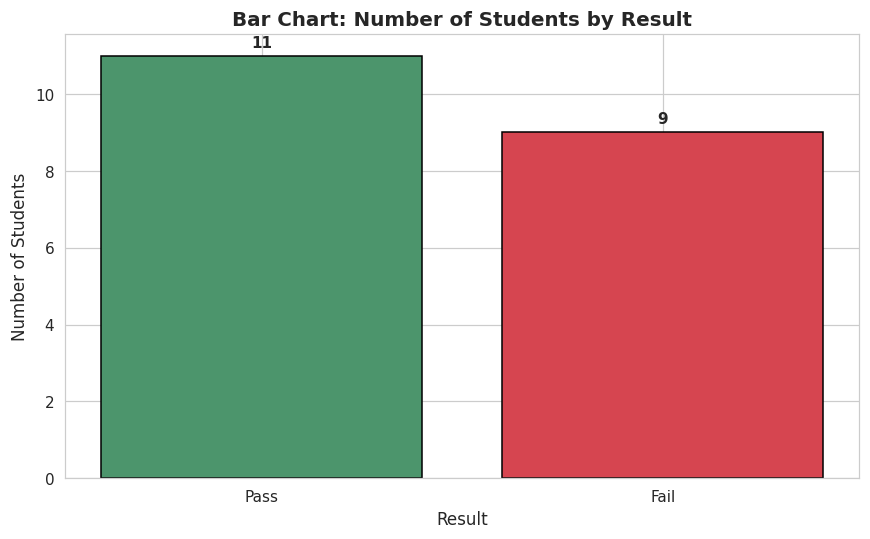

In [11]:
fig, ax = plt.subplots()
colors = ['#4C956C', '#D64550']
bars = ax.bar(result_counts.index, result_counts.values, color=colors, edgecolor='black')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15, str(int(b.get_height())),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Bar Chart: Number of Students by Result')
ax.set_xlabel('Result')
ax.set_ylabel('Number of Students')
plt.tight_layout()
plt.show()


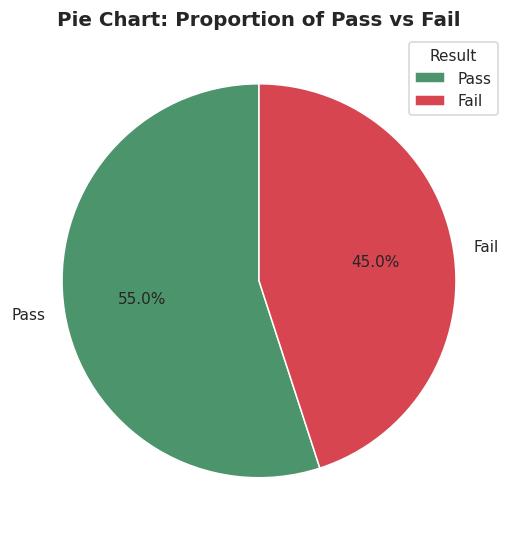

In [12]:
fig, ax = plt.subplots()
ax.pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('Pie Chart: Proportion of Pass vs Fail')
ax.legend(result_counts.index, title="Result", loc="best")
plt.tight_layout()
plt.show()


**Observation:** 11 of 20 students (55%) passed while 9 (45%) failed — a fairly balanced split between the two outcome classes.

## Task 5b: Histogram & Box Plot — Numerical Distributions

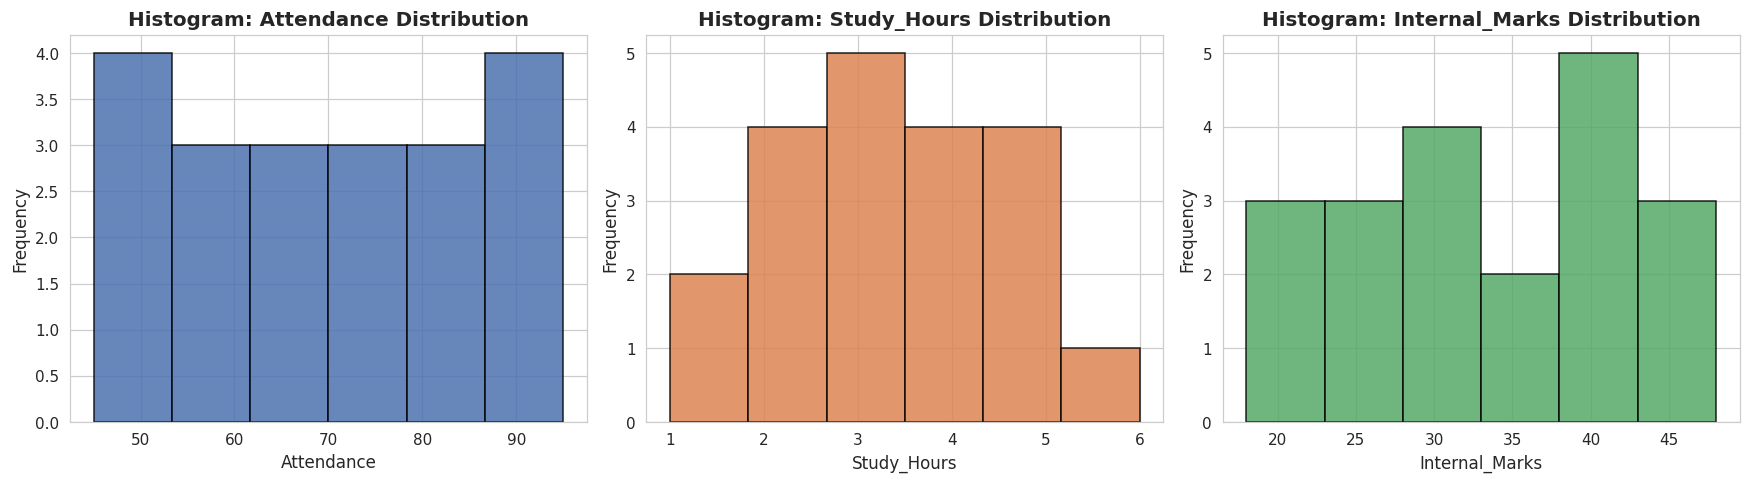

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cols = ['Attendance', 'Study_Hours', 'Internal_Marks']
colors_hist = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, c in zip(axes, cols, colors_hist):
    ax.hist(df[col], bins=6, color=c, edgecolor='black', alpha=0.85)
    ax.set_title(f'Histogram: {col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


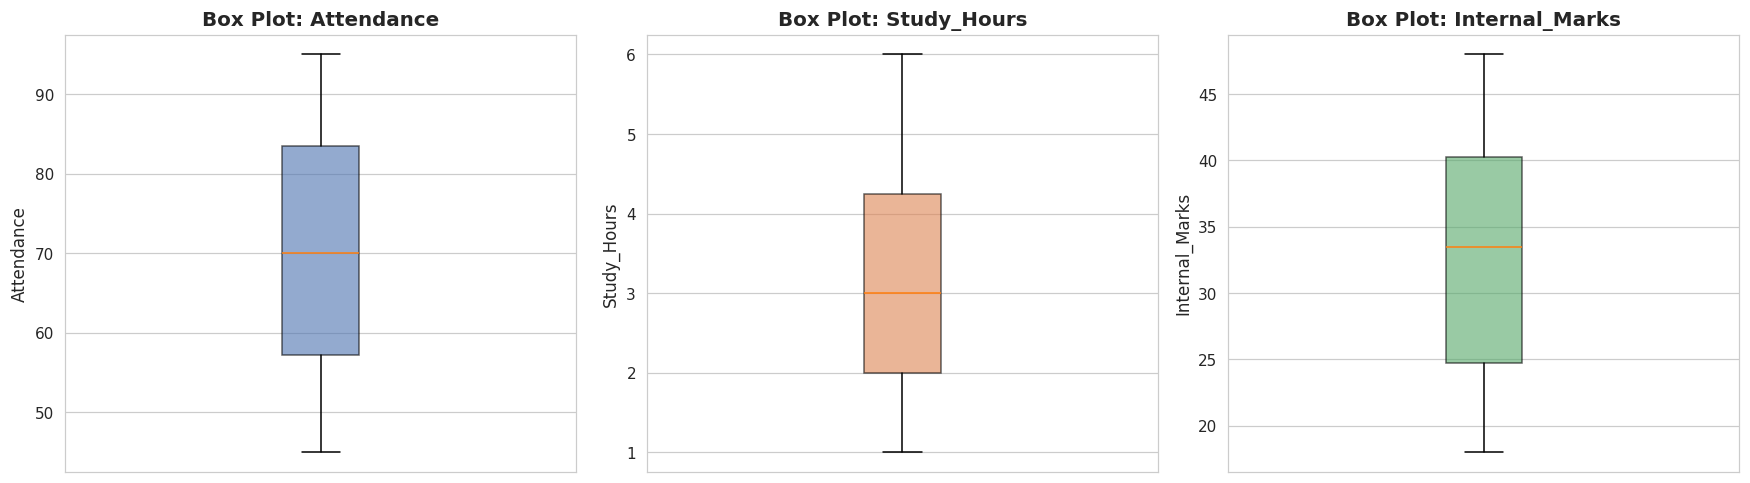

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, c in zip(axes, cols, colors_hist):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6))
    ax.set_title(f'Box Plot: {col}')
    ax.set_ylabel(col)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


**Observation:** No extreme outliers are visible in any of the three
numerical variables — the box plots show fairly symmetric spreads.
`Attendance` ranges roughly 45–95%, `Study_Hours` 1–6 hours/day, and
`Internal_Marks` 18–48 (out of 50).


## Task 6a: Important Patterns — Numeric Variables vs Result

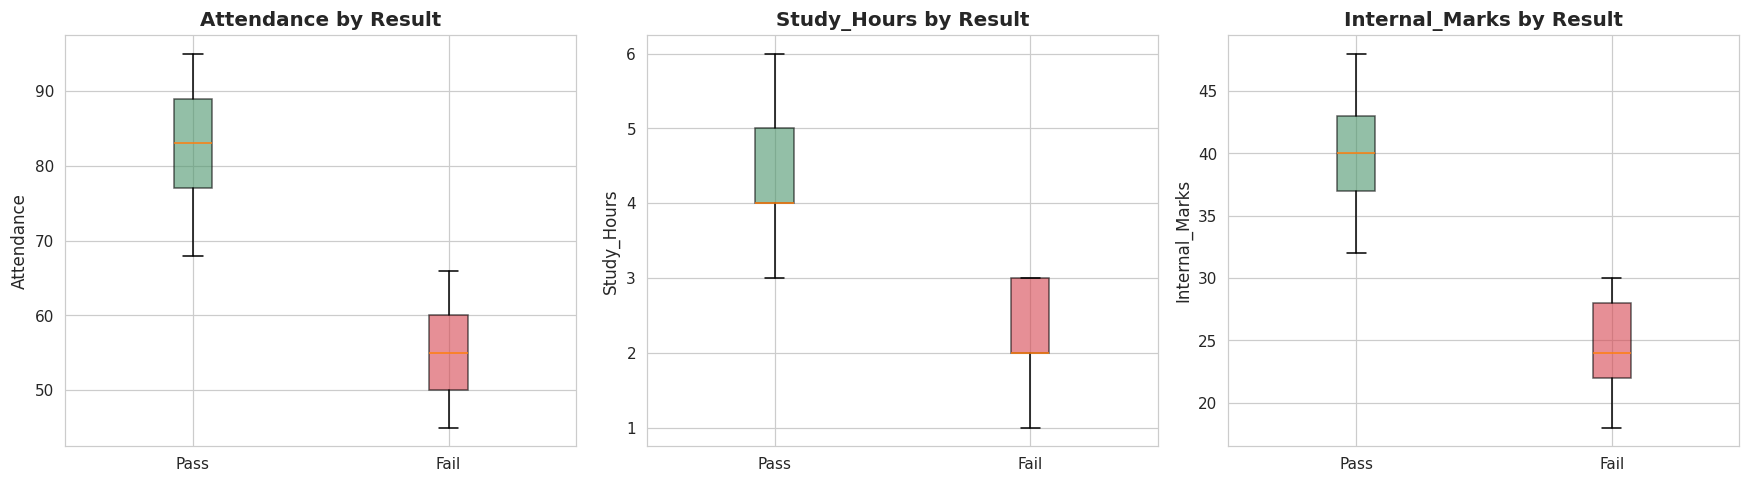

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, c in zip(axes, cols, colors_hist):
    data_pass = df[df['Result'] == 'Pass'][col]
    data_fail = df[df['Result'] == 'Fail'][col]
    bp = ax.boxplot([data_pass, data_fail], labels=['Pass', 'Fail'], patch_artist=True)
    for patch, col2 in zip(bp['boxes'], colors):
        patch.set_facecolor(col2)
        patch.set_alpha(0.6)
    ax.set_title(f'{col} by Result')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


In [16]:
group_means = df.groupby('Result', observed=True)[cols].mean().round(2)
show_df(group_means)


,Attendance,Study_Hours,Internal_Marks
Result,,,
Fail,55.11,2.11,24.33
Pass,82.45,4.36,40.00


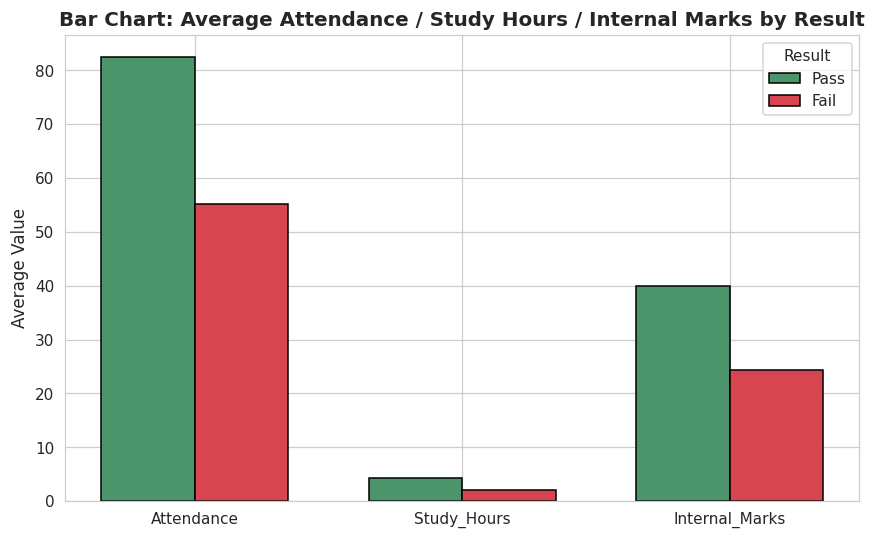

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(cols))
width = 0.35
pass_vals = group_means.loc['Pass']
fail_vals = group_means.loc['Fail']

ax.bar(x - width/2, pass_vals, width, label='Pass', color='#4C956C', edgecolor='black')
ax.bar(x + width/2, fail_vals, width, label='Fail', color='#D64550', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(cols)
ax.set_ylabel('Average Value')
ax.set_title('Bar Chart: Average Attendance / Study Hours / Internal Marks by Result')
ax.legend(title='Result')
plt.tight_layout()
plt.show()


**Observation:** Students who **Pass** have visibly higher average attendance, study hours, and internal marks than students who **Fail** — indicating all three factors move together with the final result.

## Task 5c: Scatter Plot — Bivariate Relationships

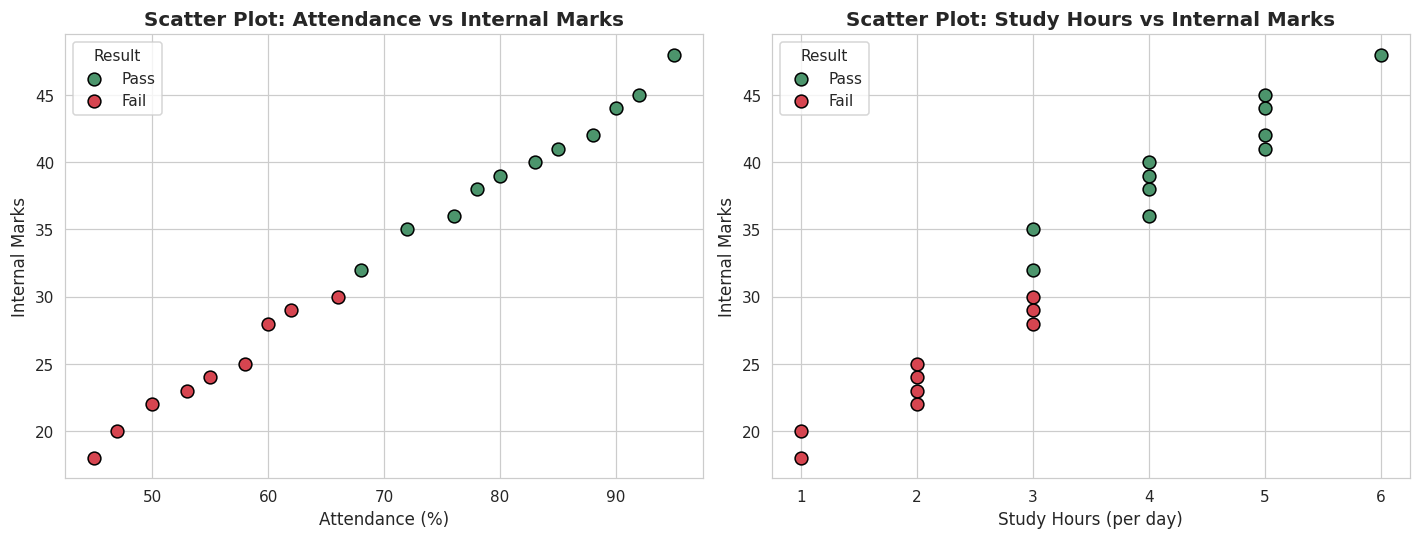

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for result, c in zip(['Pass','Fail'], colors):
    subset = df[df['Result'] == result]
    axes[0].scatter(subset['Attendance'], subset['Internal_Marks'], label=result,
                     color=c, edgecolor='black', s=70)
    axes[1].scatter(subset['Study_Hours'], subset['Internal_Marks'], label=result,
                     color=c, edgecolor='black', s=70)

axes[0].set_title('Scatter Plot: Attendance vs Internal Marks')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('Internal Marks')
axes[0].legend(title='Result')

axes[1].set_title('Scatter Plot: Study Hours vs Internal Marks')
axes[1].set_xlabel('Study Hours (per day)')
axes[1].set_ylabel('Internal Marks')
axes[1].legend(title='Result')

plt.tight_layout()
plt.show()


**Observation:** Both scatter plots show a clear **positive linear relationship** — higher attendance and more study hours are associated with higher internal marks, and higher marks students overwhelmingly fall in the `Pass` group.

## Task 5d: Line Chart — Trend Analysis (Bonus Visualization)

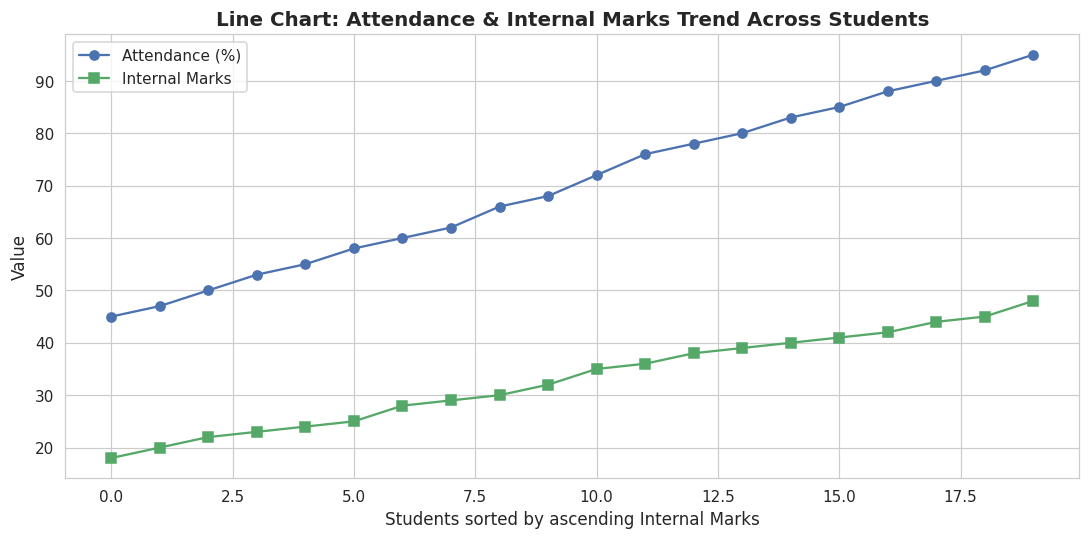

In [19]:
trend_df = df.sort_values('Internal_Marks').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(trend_df.index, trend_df['Attendance'], marker='o', color='#4C72B0', label='Attendance (%)')
ax1.plot(trend_df.index, trend_df['Internal_Marks'], marker='s', color='#55A868', label='Internal Marks')
ax1.set_xlabel('Students sorted by ascending Internal Marks')
ax1.set_ylabel('Value')
ax1.set_title('Line Chart: Attendance & Internal Marks Trend Across Students')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** When students are ordered by increasing internal marks, attendance rises almost in step with marks — visually confirming the strong association seen in the scatter plots.

## Task 6b: Important Patterns — Correlation Heatmap

In [20]:
df_corr = df.copy()
df_corr['Result_Num'] = (df_corr['Result'] == 'Pass').astype(int)
corr_matrix = df_corr[['Attendance','Study_Hours','Internal_Marks','Result_Num']].corr().round(2)
show_df(corr_matrix)


,Attendance,Study_Hours,Internal_Marks,Result_Num
Attendance,1.00,0.98,1.00,0.88
Study_Hours,0.98,1.00,0.98,0.81
Internal_Marks,1.00,0.98,1.00,0.88
Result_Num,0.88,0.81,0.88,1.00


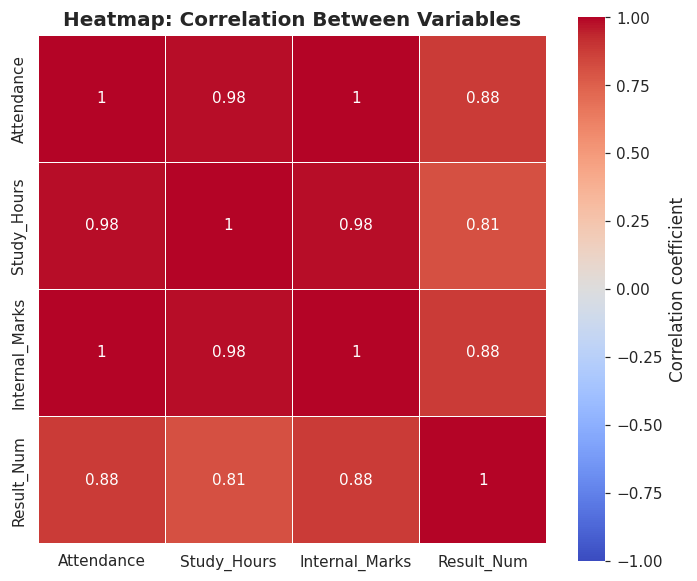

In [21]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'}, ax=ax)
ax.set_title('Heatmap: Correlation Between Variables')
plt.tight_layout()
plt.show()


**Observation:** All three predictors are **strongly positively correlated**
with each other and with passing (`Result_Num`). `Internal_Marks` shows the
highest correlation with `Result`, followed closely by `Attendance` and
`Study_Hours` — consistent with Internal Marks being partly a downstream
consequence of attendance and study effort.


## Task 7: Observations (4–5 Key Observations)

1. **Dataset is clean**: no missing values, no duplicate records, and all
   values fall within logical ranges (Attendance 0–100%, Marks 0–50).
2. **Class balance**: 55% of students passed, 45% failed — a fairly even
   split, not a severe imbalance.
3. **Attendance, Study Hours and Internal Marks are all strongly and
   positively correlated** with each other and with the final Result.
4. Passing students average noticeably higher attendance, more daily
   study hours, and higher internal marks than failing students — scatter
   plots confirm a clear, near-linear relationship with no meaningful
   outliers.
5. Internal Marks is the single strongest correlate of Result, but
   Attendance and Study Hours are useful **early indicators** available
   well before internal marks exist.

## Task 8: Conclusion

Attendance, study hours, and internal marks are the key drivers of
student results in this dataset, and their strong mutual correlation
points to a single underlying "engagement" factor. The college can use
attendance and study-hour thresholds (e.g. attendance below ~65%) as an
early-warning system to flag at-risk students before final exams and
target mentoring resources more effectively. A larger, more varied
sample would be needed before setting institution-wide policy
thresholds.
